
# Inferencia bivariada con $$\Sigma$$ conocida  
## Estimación del centro $$ (\mu_x,\mu_y) $$, región de confianza y prueba de hipótesis

**Curso:** Profundización en Estadística para Científicos de Datos  
**Formato:** Notebook autocontenido para Google Colab  
**Tema:** Inferencia en una normal bivariada con matriz de covarianzas conocida

---

## Objetivo de la clase

Desarrollar, de manera clara y paso a paso, un ejemplo aplicado de **inferencia bivariada** en el que:

1. se plantea un problema real con dos variables,
2. se define formalmente el modelo estadístico,
3. se estima el centro $$ (\mu_x,\mu_y) $$,
4. se construye la región de confianza conjunta,
5. se realiza una **prueba de hipótesis multivariada**,
6. se interpreta la decisión en contexto,
7. y se proponen ejercicios adicionales, incluyendo la versión con $$\Sigma$$ desconocida.

---

## Contexto aplicado

Un dron realiza aterrizajes de prueba sobre una plataforma rectangular.  
En cada aterrizaje se registran dos variables continuas:

- $$X$$: desviación horizontal (en metros) respecto al centro ideal,
- $$Y$$: desviación vertical (en metros) respecto al centro ideal.

Si el sistema estuviera perfectamente calibrado, el centro poblacional de aterrizaje sería:

$$
\boldsymbol{\mu} =
\begin{pmatrix}
0 \\
0
\end{pmatrix}.
$$

Sin embargo, existe la sospecha de que el dron presenta un sesgo sistemático y que el centro real de aterrizaje no coincide con el origen.

Nuestro problema será entonces:

> **¿La evidencia muestral sugiere que el centro de aterrizaje del dron coincide con el centro ideal de la plataforma?**

---

## Modelo probabilístico

Supondremos que cada aterrizaje produce un vector aleatorio

$$
\mathbf{Z}_i=
\begin{pmatrix}
X_i \\
Y_i
\end{pmatrix},
\qquad i=1,\dots,n,
$$

y que

$$
\mathbf{Z}_1,\dots,\mathbf{Z}_n \overset{iid}{\sim}\mathcal N_2(\boldsymbol{\mu},\Sigma),
$$

donde:

- $$\boldsymbol{\mu}=(\mu_x,\mu_y)^\top$$ es el **centro verdadero** que queremos inferir,
- $$\Sigma$$ es la **matriz de covarianzas conocida**.

En esta clase trabajaremos con

$$
\Sigma=
\begin{pmatrix}
1.00 & 0.60\\
0.60 & 1.44
\end{pmatrix}.
$$

Esto significa:

- $$\operatorname{Var}(X)=1.00$$,
- $$\operatorname{Var}(Y)=1.44$$,
- $$\operatorname{Cov}(X,Y)=0.60$$.

Equivalentemente,

- $$\sigma_X = 1.00$$,
- $$\sigma_Y = 1.20$$,
- $$\rho = \dfrac{0.60}{1.00\cdot 1.20}=0.50$$.

---

## Qué haremos exactamente

A partir de una muestra observada:

1. estimaremos $$\boldsymbol{\mu}$$ con la media muestral vectorial,
2. estudiaremos la distribución de $$\bar{\mathbf Z}$$,
3. construiremos la región de confianza del $$95\%$$,
4. probaremos

$$
H_0:\boldsymbol{\mu}=
\begin{pmatrix}
0\\
0
\end{pmatrix}
\quad \text{vs} \quad
H_1:\boldsymbol{\mu}\neq
\begin{pmatrix}
0\\
0
\end{pmatrix},
$$

5. y cerraremos con interpretación aplicada y ejercicios.

---

## Nota metodológica importante

En dimensión 1, con varianza conocida, la inferencia se basa en un estadístico $$Z$$.  
En dimensión 2, con matriz de covarianzas conocida, la cantidad natural es una **forma cuadrática**:

$$
n(\bar{\mathbf Z}-\boldsymbol{\mu})^\top \Sigma^{-1}(\bar{\mathbf Z}-\boldsymbol{\mu}),
$$

la cual sigue una distribución $$\chi^2$$ con 2 grados de libertad bajo el modelo.

Esa será la pieza central de toda la clase.


In [ ]:

# =========================
# 1. Librerías y utilidades
# =========================
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from scipy.stats import chi2
from matplotlib.patches import Ellipse

plt.rcParams["figure.figsize"] = (8, 6)
plt.rcParams["axes.grid"] = True
plt.rcParams["font.size"] = 11

np.set_printoptions(precision=4, suppress=True)



## 1. Generación de la muestra observada

Para que el notebook sea totalmente reproducible, simularemos una muestra con semilla fija.  
**Importante:** la lógica inferencial es exactamente la misma que usaríamos con datos reales observados.

Tomaremos:

- tamaño muestral $$n=30$$,
- centro verdadero usado para simular:  

$$
\boldsymbol{\mu}_{\text{real}}=
\begin{pmatrix}
0.55\\
-0.35
\end{pmatrix},
$$

- matriz de covarianzas conocida:

$$
\Sigma=
\begin{pmatrix}
1.00 & 0.60\\
0.60 & 1.44
\end{pmatrix}.
$$

Observa algo importante: para la **prueba de hipótesis**, el valor nulo seguirá siendo $$ (0,0) $$; el valor usado para simular solo permite construir un ejemplo concreto donde el test tenga contenido.


In [ ]:

# ==========================================
# 2. Parámetros del ejemplo y muestra simulada
# ==========================================
n = 30
mu_real = np.array([0.55, -0.35])
Sigma = np.array([[1.00, 0.60],
                  [0.60, 1.44]])

seed = 3
rng = np.random.default_rng(seed)
X = rng.multivariate_normal(mean=mu_real, cov=Sigma, size=n)

df = pd.DataFrame(X, columns=["x", "y"])
df.head()


,x,y
0,0.553560,-3.746761
1,0.578362,-1.065154
2,1.038116,0.061888
3,2.271987,1.806762
4,-0.850952,2.067421



## 2. Visualización inicial de la muestra

Antes de calcular cualquier estadístico, siempre conviene mirar los datos.  
Aquí queremos ver:

- la nube de puntos observada,
- el centro ideal $$ (0,0) $$,
- y el centro muestral $$ (\bar X,\bar Y) $$.

Esto ya da intuición visual sobre si el dron parece centrado o no.


Media muestral vectorial:
[ 0.5648 -0.3808]

Matriz de covarianzas muestral (solo descriptiva):
[[0.9257 0.4407]
 [0.4407 1.7594]]


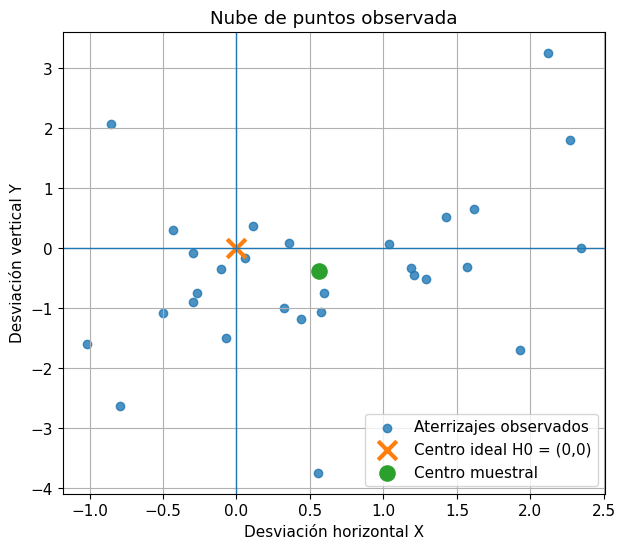

In [ ]:

# ==============================
# 3. Media muestral y dispersión
# ==============================
xbar = X.mean(axis=0)
S_muest = np.cov(X.T, ddof=1)

print("Media muestral vectorial:")
print(xbar)
print("\nMatriz de covarianzas muestral (solo descriptiva):")
print(S_muest)

plt.figure(figsize=(7, 6))
plt.scatter(df["x"], df["y"], alpha=0.8, label="Aterrizajes observados")
plt.scatter([0], [0], marker="x", s=180, linewidths=3, label="Centro ideal H0 = (0,0)")
plt.scatter([xbar[0]], [xbar[1]], marker="o", s=120, label="Centro muestral")

plt.axhline(0, linewidth=1)
plt.axvline(0, linewidth=1)
plt.xlabel("Desviación horizontal X")
plt.ylabel("Desviación vertical Y")
plt.title("Nube de puntos observada")
plt.legend()
plt.show()



## 3. Primer objeto inferencial: el parámetro de interés

El parámetro que queremos estimar es

$$
\boldsymbol{\mu}=
\begin{pmatrix}
\mu_x\\
\mu_y
\end{pmatrix}.
$$

Interpretación:

- $$\mu_x$$: desviación promedio real en el eje horizontal,
- $$\mu_y$$: desviación promedio real en el eje vertical.

En otras palabras, $$\boldsymbol{\mu}$$ es el **centro verdadero de la nube de aterrizajes**.

---

## 4. Estimador natural del centro

El estimador de $$\boldsymbol{\mu}$$ es la **media muestral vectorial**:

$$
\bar{\mathbf Z}=
\begin{pmatrix}
\bar X\\
\bar Y
\end{pmatrix},
\qquad
\bar X=\frac{1}{n}\sum_{i=1}^n X_i,\quad
\bar Y=\frac{1}{n}\sum_{i=1}^n Y_i.
$$

Esta es la extensión natural de la media muestral univariada al caso bidimensional.

En nuestro ejemplo, la estimación puntual del centro es justamente el vector `xbar` calculado arriba.


In [ ]:

# ===========================================
# 4. Distribución de la media muestral vectorial
# ===========================================
Sigma_bar = Sigma / n

print("Sigma conocida:")
print(Sigma)

print("\nCovarianza de la media muestral, Sigma/n:")
print(Sigma_bar)


Sigma conocida:
[[1.   0.6 ]
 [0.6  1.44]]

Covarianza de la media muestral, Sigma/n:
[[0.0333 0.02  ]
 [0.02   0.048 ]]


## 5. Distribución de $$\bar{\mathbf Z}$$ y origen de la distancia de Mahalanobis

Partimos del modelo:

$$
\mathbf Z_i \sim \mathcal N_p(\boldsymbol{\mu}, \Sigma), \quad i=1,\dots,n,
$$

con observaciones independientes e idénticamente distribuidas.

La media muestral es:

$$
\bar{\mathbf Z}=\frac{1}{n}\sum_{i=1}^n \mathbf Z_i,
$$

y se cumple el resultado fundamental:

$$
\bar{\mathbf Z}\sim \mathcal N_p\!\left(\boldsymbol{\mu}, \frac{\Sigma}{n}\right).
$$

Definimos el error de estimación:

$$
\mathbf W = \bar{\mathbf Z} - \boldsymbol{\mu}.
$$

Entonces:

$$
\mathbf W \sim \mathcal N_p\!\left(\mathbf 0, \frac{\Sigma}{n}\right).
$$

---

## Paso clave: estandarización multivariada

Queremos transformar $$\mathbf W$$ en un vector con:

- media cero,
- covarianza identidad,
- componentes independientes.

Es decir, buscamos:

$$
\mathbf U \sim \mathcal N_p(\mathbf 0, I).
$$

---

## Existencia de una “raíz matricial”

La matriz $$\frac{\Sigma}{n}$$ es simétrica definida positiva, por lo tanto existe una matriz $$A$$ tal que:

$$
AA^\top = \frac{\Sigma}{n}.
$$

(Esta es una descomposición tipo Cholesky o equivalente).

---

## Definición de la transformación

Definimos:

$$
\mathbf U = A^{-1}\mathbf W.
$$

---

## Demostración rigurosa de que $$\mathbf U \sim \mathcal N_p(\mathbf 0, I)$$

### 1. Normalidad

Sabemos que:

- $$\mathbf W$$ es normal multivariada,
- una transformación lineal de una normal multivariada sigue siendo normal.

Como $$\mathbf U = A^{-1}\mathbf W$$ es una transformación lineal, entonces:

$$
\mathbf U \text{ es normal multivariada}.
$$

---

### 2. Media

$$
\mathbb E(\mathbf U) = \mathbb E(A^{-1}\mathbf W) = A^{-1}\mathbb E(\mathbf W).
$$

Como $$\mathbb E(\mathbf W)=\mathbf 0$$:

$$
\mathbb E(\mathbf U)=\mathbf 0.
$$

---

### 3. Covarianza

Usamos la propiedad:

$$
\operatorname{Cov}(B\mathbf X)=B\,\operatorname{Cov}(\mathbf X)\,B^\top.
$$

Entonces:

$$
\operatorname{Cov}(\mathbf U)
=
A^{-1}\operatorname{Cov}(\mathbf W)(A^{-1})^\top.
$$

Como:

$$
\operatorname{Cov}(\mathbf W)=\frac{\Sigma}{n}=AA^\top,
$$

sustituimos:

$$
\operatorname{Cov}(\mathbf U)
=
A^{-1}(AA^\top)(A^{-1})^\top.
$$

Agrupamos:

$$
=
(A^{-1}A)\,A^\top (A^{-1})^\top.
$$

Como $$A^{-1}A=I$$:

$$
= I \cdot A^\top (A^{-1})^\top.
$$

Y como:

$$
(A^{-1})^\top = (A^\top)^{-1},
$$

entonces:

$$
A^\top (A^\top)^{-1} = I.
$$

Por tanto:

$$
\operatorname{Cov}(\mathbf U)=I.
$$

---

### 4. Conclusión

Hemos probado que:

- $$\mathbf U$$ es normal multivariada,
- $$\mathbb E(\mathbf U)=\mathbf 0$$,
- $$\operatorname{Cov}(\mathbf U)=I$$,

por lo tanto:

$$
\mathbf U \sim \mathcal N_p(\mathbf 0, I).
$$

---

## Consecuencia fundamental

Como $$\mathbf U$$ tiene covarianza identidad y es normal multivariada:

$$
U_1,\dots,U_p \sim N(0,1) \text{ independientes}.
$$

Entonces:

$$
\mathbf U^\top \mathbf U = \sum_{i=1}^p U_i^2 \sim \chi^2_p.
$$

---

## Regreso a la variable original

Recordando que:

$$
\mathbf U = A^{-1}(\bar{\mathbf Z}-\boldsymbol{\mu}),
$$

tenemos:

$$
\mathbf U^\top \mathbf U
=
(\bar{\mathbf Z}-\boldsymbol{\mu})^\top
(A^{-1})^\top A^{-1}
(\bar{\mathbf Z}-\boldsymbol{\mu}).
$$

Pero:

$$
(A^{-1})^\top A^{-1}
=
(AA^\top)^{-1}
=
\left(\frac{\Sigma}{n}\right)^{-1}
=
n\Sigma^{-1}.
$$

Por tanto:

$$
n(\bar{\mathbf Z}-\boldsymbol{\mu})^\top \Sigma^{-1}(\bar{\mathbf Z}-\boldsymbol{\mu})
\sim \chi^2_p.
$$

---

## Interpretación final

La cantidad

$$
(\mathbf x-\boldsymbol{\mu})^\top \Sigma^{-1}(\mathbf x-\boldsymbol{\mu})
$$

es la **distancia de Mahalanobis al cuadrado**.

No es una fórmula arbitraria:

> surge de transformar el espacio para eliminar correlaciones y escalar adecuadamente, y luego medir distancia euclidiana.

---

## Insight clave

- En dimensión 1: estandarizas dividiendo por $$\sigma$$  
- En dimensión $$p$$: estandarizas multiplicando por $$A^{-1}$$  

👉 La distancia de Mahalanobis es la distancia euclidiana en ese espacio estandarizado.

---

## Caso particular

Si $$p=2$$:

$$
n(\bar{\mathbf Z}-\boldsymbol{\mu})^\top \Sigma^{-1}(\bar{\mathbf Z}-\boldsymbol{\mu})
\sim \chi^2_2.
$$

---

## Generalización

En dimensión general:

$$
n(\bar{\mathbf Z}-\boldsymbol{\mu})^\top \Sigma^{-1}(\bar{\mathbf Z}-\boldsymbol{\mu})
\sim \chi^2_p.
$$

Los grados de libertad coinciden exactamente con la dimensión del problema.

In [ ]:
# ===========================================
# Visualización dinámica de Mahalanobis y χ²
# ===========================================
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import chi2
import ipywidgets as widgets
from ipywidgets import interact

def mahalanobis_demo(rho=0.5, sigma_x=1.0, sigma_y=1.2, n=500, seed=1):

    np.random.seed(seed)

    # Construcción de Sigma
    cov_xy = rho * sigma_x * sigma_y
    Sigma = np.array([[sigma_x**2, cov_xy],
                      [cov_xy, sigma_y**2]])

    mu = np.array([0, 0])

    # Simulación
    X = np.random.multivariate_normal(mu, Sigma, size=n)

    # Cálculo de distancias de Mahalanobis
    Sigma_inv = np.linalg.inv(Sigma)
    D2 = np.array([
        x.T @ Sigma_inv @ x for x in X
    ])

    # =========================
    # Gráficos
    # =========================
    fig, axs = plt.subplots(1, 2, figsize=(12,5))

    # Nube de puntos
    axs[0].scatter(X[:,0], X[:,1], alpha=0.5)
    axs[0].set_title("Nube de datos")
    axs[0].axhline(0)
    axs[0].axvline(0)

    # Histograma de Mahalanobis
    axs[1].hist(D2, bins=30, density=True, alpha=0.6, label="Empírico")

    x_vals = np.linspace(0, np.max(D2), 200)
    axs[1].plot(x_vals, chi2.pdf(x_vals, df=2), linewidth=2, label="Chi-cuadrado teórica")

    axs[1].set_title("Distribución de distancias de Mahalanobis")
    axs[1].legend()

    plt.show()

    print("Sigma =\n", np.round(Sigma,3))
    print("\nMedia empírica de D²:", np.round(np.mean(D2),3))
    print("Esperanza teórica χ²(2):", 2)

# Sliders
interact(
    mahalanobis_demo,
    rho=widgets.FloatSlider(value=0.5, min=-0.9, max=0.9, step=0.1),
    sigma_x=widgets.FloatSlider(value=1.0, min=0.5, max=2.5, step=0.1),
    sigma_y=widgets.FloatSlider(value=1.2, min=0.5, max=2.5, step=0.1),
    n=widgets.IntSlider(value=500, min=100, max=2000, step=100),
    seed=widgets.IntSlider(value=1, min=1, max=100)
);

interactive(children=(FloatSlider(value=0.5, description='rho', max=0.9, min=-0.9), FloatSlider(value=1.0, des…

In [ ]:

# ======================================================
# 5. Funciones auxiliares para elipse y forma cuadrática
# ======================================================
def quad_form(mu_candidate, xbar, Sigma, n):
    d = xbar - mu_candidate
    return n * d.T @ np.linalg.inv(Sigma) @ d

def confidence_ellipse_from_cov(mean, cov, level=0.95, ax=None, label=None, **kwargs):
    if ax is None:
        ax = plt.gca()

    c2 = chi2.ppf(level, df=2)

    eigvals, eigvecs = np.linalg.eigh(cov)
    order = eigvals.argsort()[::-1]
    eigvals = eigvals[order]
    eigvecs = eigvecs[:, order]

    width = 2 * np.sqrt(c2 * eigvals[0])
    height = 2 * np.sqrt(c2 * eigvals[1])

    angle = np.degrees(np.arctan2(*eigvecs[:, 0][::-1]))

    ell = Ellipse(
        xy=mean, width=width, height=height, angle=angle,
        fill=False, label=label, **kwargs
    )
    ax.add_patch(ell)
    return ell



## 7. Región de confianza conjunta del 95% para $$\boldsymbol{\mu}$$

Una región de confianza del $$95\%$$ para el verdadero centro es

$$
\mathcal C_{0.95}
=
\left\{
\boldsymbol{\mu}:
n(\bar{\mathbf Z}-\boldsymbol{\mu})^\top
\Sigma^{-1}
(\bar{\mathbf Z}-\boldsymbol{\mu})
\le
\chi^2_{2,0.95}
\right\}.
$$

Como $$\chi^2_{2,0.95}\approx 5.991$$, la frontera de la región es una **elipse**.

Observa el significado conceptual:

- el centro de la elipse es $$\bar{\mathbf Z}$$,
- la forma de la elipse depende de $$\Sigma$$,
- el tamaño depende de $$n$$ y del nivel de confianza.

Esta región es el análogo multivariado del intervalo de confianza univariado.


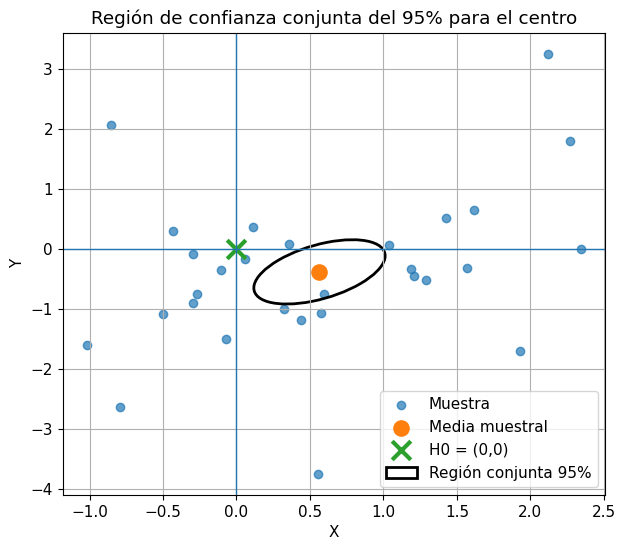

In [ ]:

# ===========================================
# 6. Elipse de confianza conjunta del 95%
# ===========================================
plt.figure(figsize=(7, 6))
ax = plt.gca()

plt.scatter(df["x"], df["y"], alpha=0.7, label="Muestra")
plt.scatter([xbar[0]], [xbar[1]], s=120, label="Media muestral")
plt.scatter([0], [0], marker="x", s=180, linewidths=3, label="H0 = (0,0)")

confidence_ellipse_from_cov(
    mean=xbar, cov=Sigma / n, level=0.95, ax=ax,
    linewidth=2, label="Región conjunta 95%"
)

plt.axhline(0, linewidth=1)
plt.axvline(0, linewidth=1)
plt.xlabel("X")
plt.ylabel("Y")
plt.title("Región de confianza conjunta del 95% para el centro")
plt.legend()
plt.show()



## 8. Prueba de hipótesis multivariada

Queremos contrastar:

$$
H_0:
\boldsymbol{\mu}=
\begin{pmatrix}
0\\
0
\end{pmatrix}
\qquad \text{vs} \qquad
H_1:
\boldsymbol{\mu}\neq
\begin{pmatrix}
0\\
0
\end{pmatrix}.
$$

El estadístico de prueba es

$$
T =
n(\bar{\mathbf Z}-\boldsymbol{\mu}_0)^\top
\Sigma^{-1}
(\bar{\mathbf Z}-\boldsymbol{\mu}_0),
$$

donde

$$
\boldsymbol{\mu}_0=
\begin{pmatrix}
0\\
0
\end{pmatrix}.
$$

Bajo $$H_0$$,

$$
T \sim \chi^2_2.
$$

La regla de decisión al nivel $$\alpha=0.05$$ es:

- **rechazar $$H_0$$** si $$T > \chi^2_{2,0.95}$$,
- **no rechazar $$H_0$$** en caso contrario.

Notarás que esto es completamente análogo al caso univariado con $$Z$$, excepto que ahora la distancia relevante es multivariada.


In [ ]:

# ===========================================
# 7. Cálculo del estadístico y decisión del test
# ===========================================
mu0 = np.array([0.0, 0.0])
T = quad_form(mu0, xbar, Sigma, n)
crit = chi2.ppf(0.95, df=2)
p_value = 1 - chi2.cdf(T, df=2)

print(f"Media muestral = {xbar}")
print(f"Estadístico T = {T:.4f}")
print(f"Valor crítico chi2_2,0.95 = {crit:.4f}")
print(f"p-value = {p_value:.6f}")

if T > crit:
    print("\nDecisión: RECHAZAR H0 al 5%.")
else:
    print("\nDecisión: NO rechazar H0 al 5%.")


Media muestral = [ 0.5648 -0.3808]
Estadístico T = 23.9556
Valor crítico chi2_2,0.95 = 5.9915
p-value = 0.000006

Decisión: RECHAZAR H0 al 5%.



## 9. Interpretación estadística y aplicada

La decisión formal se basa en comparar la distancia multivariada entre la media muestral observada y el valor nulo $$ (0,0) $$ con lo que sería razonable observar si $$H_0$$ fuera cierta.

### Interpretación estadística
- Si el estadístico resulta muy grande, la media muestral cae demasiado lejos del valor nulo en términos de la métrica inducida por $$\Sigma^{-1}$$.
- Eso constituye evidencia contra $$H_0$$.

### Interpretación aplicada
- **Rechazar $$H_0$$** significa que la muestra sugiere que el dron **no está centrado** en el objetivo.
- **No rechazar $$H_0$$** significa que la muestra no ofrece evidencia suficiente para afirmar un desplazamiento sistemático del centro.

Un punto fino pero importante:

> **No rechazar $$H_0$$ no prueba que el dron esté perfectamente calibrado.**  
> Solo indica que, con esta muestra y este nivel de significancia, no hay evidencia suficiente para afirmar lo contrario.

---

## 10. Conexión entre test y región de confianza

Existe una equivalencia geométrica muy importante:

- si $$\boldsymbol{\mu}_0$$ **cae dentro** de la región de confianza del 95%, entonces **no se rechaza** $$H_0$$ al 5%,
- si $$\boldsymbol{\mu}_0$$ **cae fuera** de la región, entonces **se rechaza** $$H_0$$.

Eso hace visible la relación entre inferencia por intervalos/regiones e inferencia por pruebas.


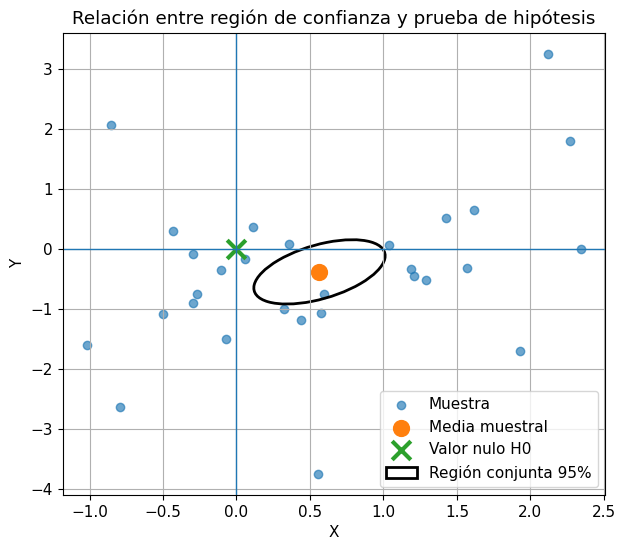

In [ ]:

# ===========================================
# 8. Visualización de la decisión del test
# ===========================================
plt.figure(figsize=(7, 6))
ax = plt.gca()

plt.scatter(df["x"], df["y"], alpha=0.65, label="Muestra")
plt.scatter([xbar[0]], [xbar[1]], s=130, label="Media muestral")
plt.scatter([mu0[0]], [mu0[1]], marker="x", s=180, linewidths=3, label="Valor nulo H0")

confidence_ellipse_from_cov(
    mean=xbar, cov=Sigma / n, level=0.95, ax=ax,
    linewidth=2, label="Región conjunta 95%"
)

plt.axhline(0, linewidth=1)
plt.axvline(0, linewidth=1)
plt.xlabel("X")
plt.ylabel("Y")
plt.title("Relación entre región de confianza y prueba de hipótesis")
plt.legend()
plt.show()



## 11. Deducción final del ejemplo

Con los datos simulados en este notebook se obtiene un estadístico de prueba que debe compararse con el valor crítico de la distribución $$\chi^2_2$$ al 5%.

### Conclusión formal
- Si $$T > \chi^2_{2,0.95}$$, se **rechaza** la hipótesis nula  

$$
H_0:\boldsymbol{\mu}=(0,0)^\top.
$$

- Si $$T \le \chi^2_{2,0.95}$$, **no se rechaza** $$H_0$$.

### Conclusión en contexto
La decisión final debe leerse así:

- **rechazar $$H_0$$**: la evidencia muestral indica un **desplazamiento sistemático** respecto al centro ideal,
- **no rechazar $$H_0$$**: la muestra no ofrece evidencia suficiente para afirmar que el dron esté descentrado.

### Lectura conceptual correcta
- El problema no se resuelve mirando $$X$$ y $$Y$$ por separado.
- Se resuelve de manera **conjunta**, teniendo en cuenta:
  - la variabilidad de cada coordenada,
  - y la correlación entre ambas.

Ese es precisamente el valor de la inferencia multivariada.



# Sección interactiva: sliders para construir intuición

En esta sección podrás mover algunos parámetros y ver cómo cambian:

- la nube de puntos,
- la media muestral,
- la región de confianza,
- y la posición relativa del valor nulo.




In [ ]:

# ===========================================
# 9. Activación de widgets en Google Colab
# ===========================================
try:
    from google.colab import output
    output.enable_custom_widget_manager()
except Exception:
    pass


In [ ]:

# ===========================================
# 10. Controles interactivos con ipywidgets
# ===========================================
import ipywidgets as widgets
from ipywidgets import interact

def interactive_bivariate_inference(mu_x=0.5, mu_y=-0.3, sigma_x=1.0, sigma_y=1.2, rho=0.5, n=30, seed=7):
    cov_xy = rho * sigma_x * sigma_y
    Sigma_int = np.array([[sigma_x**2, cov_xy],
                          [cov_xy, sigma_y**2]])
    mu_int = np.array([mu_x, mu_y])

    rng = np.random.default_rng(seed)
    sample = rng.multivariate_normal(mu_int, Sigma_int, size=n)
    xbar_int = sample.mean(axis=0)
    mu0_int = np.array([0.0, 0.0])

    T_int = n * (xbar_int - mu0_int).T @ np.linalg.inv(Sigma_int) @ (xbar_int - mu0_int)
    crit_int = chi2.ppf(0.95, df=2)
    p_int = 1 - chi2.cdf(T_int, df=2)

    fig, ax = plt.subplots(figsize=(7, 6))
    ax.scatter(sample[:, 0], sample[:, 1], alpha=0.7, label="Muestra")
    ax.scatter([xbar_int[0]], [xbar_int[1]], s=120, label="Media muestral")
    ax.scatter([0], [0], marker="x", s=170, linewidths=3, label="H0=(0,0)")

    confidence_ellipse_from_cov(
        mean=xbar_int, cov=Sigma_int/n, level=0.95, ax=ax,
        linewidth=2, label="Región conjunta 95%"
    )

    ax.axhline(0, linewidth=1)
    ax.axvline(0, linewidth=1)
    ax.set_title("Inferencia bivariada interactiva")
    ax.set_xlabel("X")
    ax.set_ylabel("Y")
    ax.legend()
    plt.show()

    print("Media muestral:", np.round(xbar_int, 4))
    print("Sigma usada:\n", np.round(Sigma_int, 4))
    print(f"Estadístico T = {T_int:.4f}")
    print(f"Valor crítico = {crit_int:.4f}")
    print(f"p-value = {p_int:.6f}")
    print("Decisión:", "RECHAZAR H0" if T_int > crit_int else "NO rechazar H0")

interact(
    interactive_bivariate_inference,
    mu_x=widgets.FloatSlider(value=0.5, min=-1.5, max=1.5, step=0.1, description="mu_x"),
    mu_y=widgets.FloatSlider(value=-0.3, min=-1.5, max=1.5, step=0.1, description="mu_y"),
    sigma_x=widgets.FloatSlider(value=1.0, min=0.4, max=2.5, step=0.1, description="sigma_x"),
    sigma_y=widgets.FloatSlider(value=1.2, min=0.4, max=2.5, step=0.1, description="sigma_y"),
    rho=widgets.FloatSlider(value=0.5, min=-0.9, max=0.9, step=0.1, description="rho"),
    n=widgets.IntSlider(value=30, min=8, max=150, step=2, description="n"),
    seed=widgets.IntSlider(value=7, min=1, max=200, step=1, description="seed")
);


interactive(children=(FloatSlider(value=0.5, description='mu_x', max=1.5, min=-1.5), FloatSlider(value=-0.3, d…


## 12. Qué debería observar el estudiante con los sliders

### Al mover $$\mu_x$$ y $$\mu_y$$
La nube y la media muestral se desplazan.  
Si el desplazamiento es suficientemente grande, el valor nulo $$ (0,0) $$ queda fuera de la región conjunta y se rechaza $$H_0$$.

### Al mover $$n$$
La región conjunta se hace más pequeña cuando $$n$$ aumenta, porque la incertidumbre de $$\bar{\mathbf Z}$$ disminuye.

### Al mover $$\rho$$
La elipse cambia de inclinación.  
Esto muestra que la inferencia multivariada depende críticamente de la correlación entre variables.

### Al mover $$\sigma_x$$ y $$\sigma_y$$
Cambian las escalas y, por tanto, la forma y amplitud de la región de confianza.

---

## 13. Comparación con el caso univariado

En una sola variable, con varianza conocida, el estadístico es:

$$
Z=\frac{\bar X-\mu_0}{\sigma/\sqrt{n}}.
$$

En dos variables, con $$\Sigma$$ conocida, el análogo no es una simple suma de dos $$Z$$, sino la forma cuadrática:

$$
T=
n(\bar{\mathbf Z}-\boldsymbol{\mu}_0)^\top
\Sigma^{-1}
(\bar{\mathbf Z}-\boldsymbol{\mu}_0).
$$

Diferencia conceptual decisiva:

- el caso univariado mide distancia en una recta,
- el caso bivariado mide distancia en un espacio donde la covarianza importa.



# Ejercicios propuestos

A continuación se proponen ejercicios para afianzar y extender el material.

---

## Ejercicio 1. Repetición completa del ejemplo con otro valor nulo

En el contexto del dron, considere ahora la hipótesis

$$
H_0:\boldsymbol{\mu}=
\begin{pmatrix}
0.4\\
-0.2
\end{pmatrix}.
$$

1. Calcule el estadístico de prueba correspondiente.
2. Determine la región de rechazo al 5%.
3. Decida si se rechaza o no $$H_0$$.
4. Interprete la decisión en contexto.

---

## Ejercicio 2. Región de confianza con otro nivel

Usando la misma muestra y la misma $$\Sigma$$:

1. construya la región de confianza conjunta del 99%,
2. grafíquela sobre la nube de puntos,
3. compare su tamaño con la región del 95%,
4. explique por qué cambia.

---

## Ejercicio 3. Sensibilidad al tamaño muestral

Manteniendo fija la misma $$\Sigma$$ y un centro verdadero no nulo:

1. simule muestras con $$n=10,30,80$$,
2. calcule la media muestral y la región de confianza en cada caso,
3. compare visualmente las elipses,
4. explique el efecto de $$n$$ sobre la precisión inferencial.

---

## Ejercicio 4. Qué falla si se ignora la covarianza

Repita el análisis suponiendo incorrectamente que

$$
\Sigma=
\begin{pmatrix}
1.00 & 0\\
0 & 1.44
\end{pmatrix}.
$$

1. calcule el nuevo estadístico,
2. compare la decisión con la obtenida usando la matriz correcta,
3. explique por qué ignorar la covarianza puede conducir a conclusiones erradas.

---

## Ejercicio 5. Caso con $$\Sigma$$ desconocida

En la práctica, muchas veces $$\Sigma$$ no es conocida.  
En ese caso, se reemplaza por la matriz de covarianzas muestral $$S$$, y aparece la versión multivariada del estadístico t: el **estadístico $$T^2$$ de Hotelling**.

### Definiciones necesarias

Si

$$
\mathbf Z_1,\dots,\mathbf Z_n \overset{iid}{\sim} \mathcal N_p(\boldsymbol{\mu},\Sigma),
$$

con $$\Sigma$$ desconocida, entonces:

- la media muestral vectorial es

$$
\bar{\mathbf Z}=\frac{1}{n}\sum_{i=1}^n \mathbf Z_i,
$$

- la covarianza muestral es

$$
S=\frac{1}{n-1}\sum_{i=1}^n(\mathbf Z_i-\bar{\mathbf Z})(\mathbf Z_i-\bar{\mathbf Z})^\top.
$$

Para contrastar

$$
H_0:\boldsymbol{\mu}=\boldsymbol{\mu}_0,
$$

se usa

$$
T^2 = n(\bar{\mathbf Z}-\boldsymbol{\mu}_0)^\top S^{-1}(\bar{\mathbf Z}-\boldsymbol{\mu}_0).
$$

Cuando el modelo es normal multivariado, se tiene la transformación:

$$
\frac{n-p}{p(n-1)}\,T^2 \sim F_{p,n-p}
\quad \text{bajo } H_0.
$$

### Tareas

1. Escriba el estadístico $$T^2$$ para $$p=2$$.
2. Determine la regla de rechazo al nivel $$\alpha=0.05$$.
3. Rehaga el análisis del dron usando $$S$$ en lugar de $$\Sigma$$.
4. Compare conceptualmente este caso con el de $$\Sigma$$ conocida.

---

## Ejercicio 6. Derivación conceptual de la forma cuadrática

Sea

$$
\bar{\mathbf Z}\sim \mathcal N_2\left(\boldsymbol{\mu}, \frac{\Sigma}{n}\right).
$$

1. Defina $$\mathbf W=\bar{\mathbf Z}-\boldsymbol{\mu}$$.
2. Considere una matriz $$A$$ tal que $$AA^\top=\Sigma/n$$.
3. Defina $$\mathbf U=A^{-1}\mathbf W$$.
4. Muestre que $$\mathbf U\sim\mathcal N_2(\mathbf 0,I)$$.
5. Deduzca que

$$
\mathbf U^\top \mathbf U \sim \chi^2_2.
$$

6. Reescriba $$\mathbf U^\top \mathbf U$$ en términos de $$\bar{\mathbf Z}$$, $$\boldsymbol{\mu}$$, $$\Sigma$$ y $$n$$.

---

## Ejercicio 7. Interpretación geométrica

Explique, con apoyo gráfico, por qué la región de confianza es una elipse y no un rectángulo.  
En su respuesta, discuta:

- el papel de $$\Sigma^{-1}$$,
- el efecto de la correlación,
- la relación entre autovalores/autovectores y orientación de la elipse.



# Cierre conceptual

## Ideas clave que deben quedar firmes

1. En inferencia bivariada, el parámetro de interés es un **vector**:

$$
\boldsymbol{\mu}=(\mu_x,\mu_y)^\top.
$$

2. El estimador natural es la **media muestral vectorial**:

$$
\bar{\mathbf Z}.
$$

3. Cuando $$\Sigma$$ es conocida:

$$
\bar{\mathbf Z}\sim \mathcal N_2\left(\boldsymbol{\mu}, \frac{\Sigma}{n}\right).
$$

4. La herramienta central es la forma cuadrática:

$$
n(\bar{\mathbf Z}-\boldsymbol{\mu})^\top \Sigma^{-1}(\bar{\mathbf Z}-\boldsymbol{\mu}),
$$

que bajo el modelo sigue una $$\chi^2_2$$.

5. La región de confianza conjunta es una **elipse**.

6. La prueba de hipótesis sobre el centro es el análogo multivariado de la prueba Z univariada, pero ajustando por covarianza.

7. Si $$\Sigma$$ es desconocida, el objeto natural ya no es una $$\chi^2$$ directa, sino el estadístico $$T^2$$ de Hotelling, relacionado con una distribución $$F$$.

---

## Mensaje final para el estudiante

La idea profunda no es memorizar fórmulas.  
La idea profunda es entender que, en varias dimensiones, **la distancia relevante depende de la estructura de covarianza**.  

Ese es el núcleo geométrico y probabilístico de la inferencia multivariada.
